In [33]:
!git clone https://github.com/tanishq-latent/Credit-Risk-Assesment-using-SHAP.git

fatal: destination path 'Credit-Risk-Assesment-using-SHAP' already exists and is not an empty directory.


In [34]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_squared_error,
    r2_score
)

# Ignore Warnings
# import warnings
# warnings.filterwarnings('ignore')

In [35]:
df = pd.read_csv('/content/Credit-Risk-Assesment-using-SHAP/credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


#2. Exploratory Data Analysis (EDA)

In [36]:
df.shape

(32581, 12)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [38]:
#missing values
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [39]:
df['loan_status'].unique()

array([1, 0])

In [40]:
df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


In [41]:
df.duplicated().sum()

np.int64(165)

In [42]:
df.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


<Axes: xlabel='loan_status', ylabel='count'>

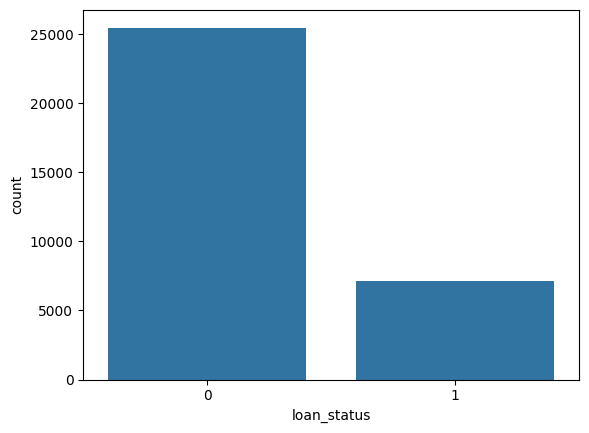

In [43]:
sns.countplot(x='loan_status',data=df)

In [44]:
# we can solve this smote or class weight

In [45]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


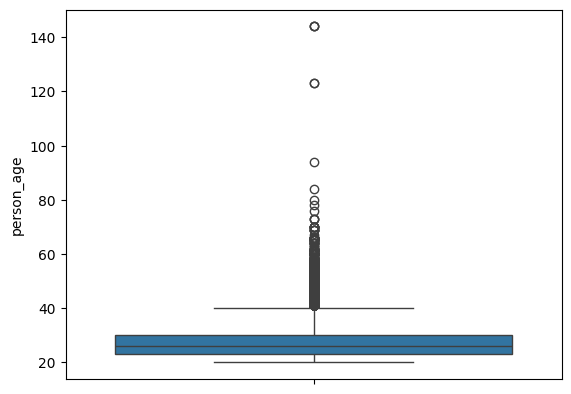

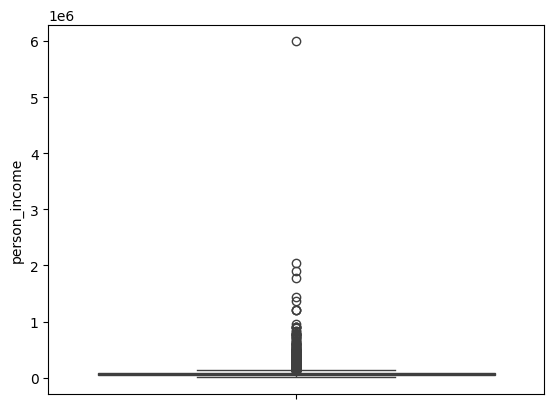

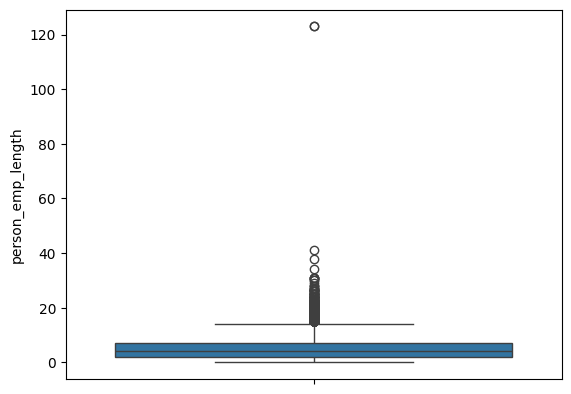

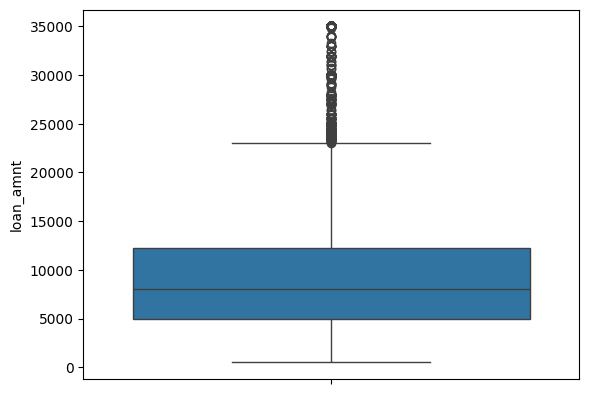

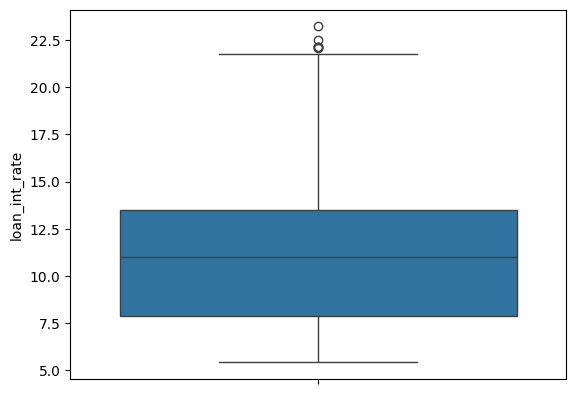

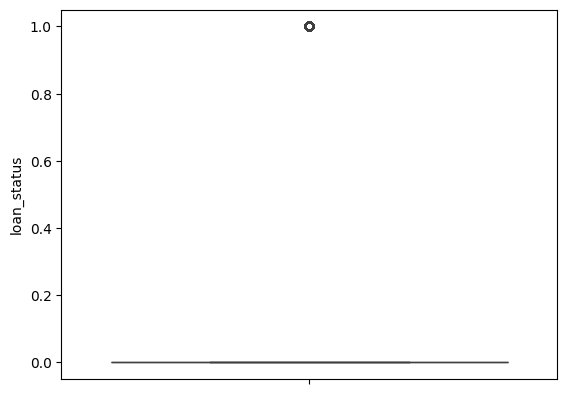

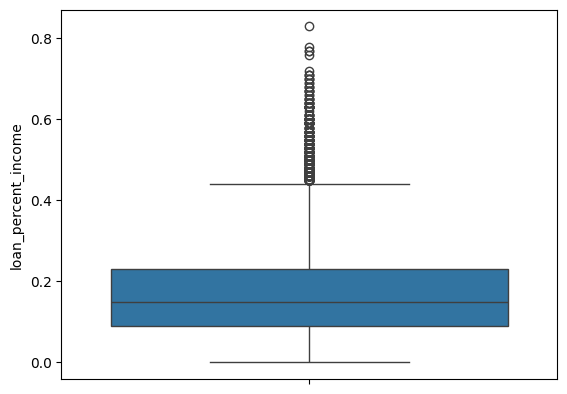

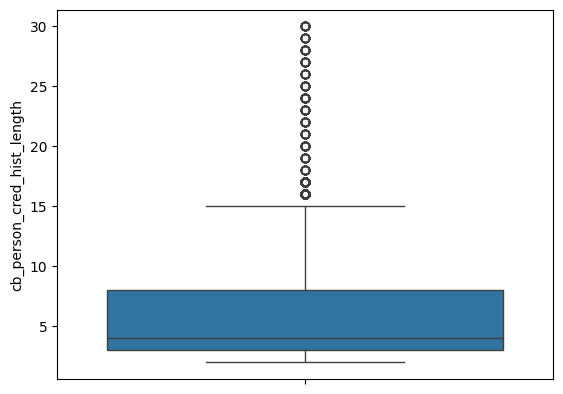

In [46]:
num_cols = df.select_dtypes(include=np.number).columns
for i in num_cols:
  sns.boxplot(df[i])
  plt.show()



In [47]:
df[df['person_age']>100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


In [48]:
df[df['person_emp_length']>60]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


<Axes: >

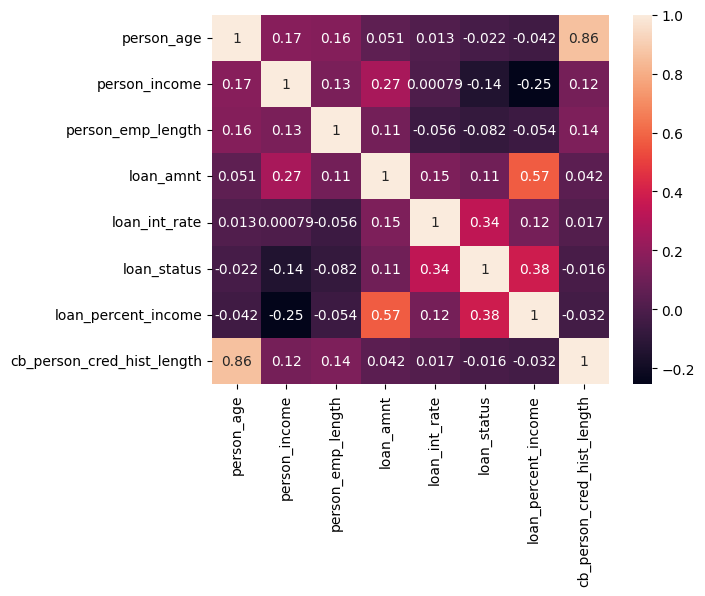

In [49]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

#3. Data Validation & Outlier Handling

In [50]:
df_copy = df.copy()

In [51]:
#remove duplicate rows
print(f'Original Rows : {df_copy.shape[0]}')
df_copy.drop_duplicates(inplace=True)
print(f'After Removing Duplicates : {df_copy.shape[0]}')

Original Rows : 32581
After Removing Duplicates : 32416


In [52]:
#remove ages below 18 or above 100
df_copy = df_copy[(df_copy['person_age'] >= 18) & (df_copy['person_age'] <= 100)]

In [53]:
#Remove employment length greater than age or extreme outliers (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

#Remove the rows with zero or negative income and loan amount.
df_copy = df_copy[df_copy['loan_amnt'] > 0]

#check if the interest rate looks realistic.
print("Loan intreset rate range from (min: 5.42 and max: 23.22)")

Loan intreset rate range from (min: 5.42 and max: 23.22)



#4. Features, Target & Train-Test Split

In [54]:
X = df_copy.drop('loan_status',axis=1)
y = df_copy['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
# stratify=y ratio maintain karta hai
# Ab dono datasets mein 80:20 ka ratio maintain hai.

In [55]:
y.value_counts()

,count
loan_status,
0,24715
1,6807


In [56]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

In [57]:
y_train.value_counts()

,count
loan_status,
0,19772
1,5445


In [58]:
# 19772/5445
neg,pos = np.bincount(y_train)
class_weights = neg/pos
class_weights

np.float64(3.6312213039485766)

In [59]:
5445*class_weights

np.float64(19772.0)

In [60]:
#Logistic Regression : impute + SCALE Numeric, impute + One-Hot-Encoding
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [61]:
preprocessor_lr = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

In [62]:
#XGBoost: Impute numeric only (No Scaling), impute + One - Hot Encoding
preprocessor_xg = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols),

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

#7. Evaluation Helper Function
We build one common function to check any model's performance.
It will show accuracy, precision, recall, F1 score, and more.
It will also show a confusion matrix and a precision-recall curve.

In [63]:

#We have to evaluate Logistic Model and XGBoost model on the basis of their metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve

def eval_model(model_name,model,X_test,y_test):
  y_pred = model.predict(X_test)
  y_pred_prob = model.predict_proba(X_test)[:,1]

  #metrices
  accuracy_score = accuracy_score(y_test,y_pred)
  precision_score = precision_score(y_test,y_pred)
  recall_score = recall_score(y_test,y_pred)
  f1_score = f1_score(y_test,y_pred)
  print(f"Accuracy : {accuracy:.2f}")
  print(f"Precision : {precision:.2f}")
  print(f"Recall : {recall:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)

  #confusion matrix
  cm  = confusion_matrix(y_test,y_pred)
  class_report = classification_report(y_test,y_pred)

  sns.heatmap(cm,annot=True,fmt='g')
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()

  precsions, recalls, thersholds = precisoin_recall_curve(y_test,y_pred_prob)
  plt.plot(recalls,precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")

In [64]:
# eval_model("basic lr ",)

#8. Stratified Cross-Validation
One single train-test split may not be reliable.
We split the training data into five folds instead.
Each fold keeps the same default vs repaid ratio.
We check the model's score across all folds.

In [65]:

from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [66]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])


In [67]:
lr_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [68]:
from xgboost import XGBClassifier

xgb_cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_xg),
        (
            "classifier",
            XGBClassifier(
                n_estimators=1000,
                learning_rate=0.01,
                scale_pos_weight=class_weights,
                random_state=42,
            ),
        ),
    ]
)
xgb_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=1000, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [69]:


for cv_name, pipe in [("Logistic Regression", lr_cv_pipeline),
                      ("XGBoost", xgb_cv_pipeline)]:

                      cv_results = cross_validate(pipe, X_train , y_train, cv=cv, scoring=scoring, n_jobs=-1)

                      print(cv_name)
                      print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
                      print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
                      print(f"Precision : {cv_results['test_precision'].mean()}")
                      print(f"Recall : {cv_results['test_recall'].mean()}")
                      print(f"F1 : {cv_results['test_f1'].mean()}")
                      print()

Logistic Regression
ROC-AUC : 0.8705112830525306
Accuracy : 0.8115949542892269
Precision : 0.5448226008889892
Recall : 0.7781450872359963
F1 : 0.6408013995933108

XGBoost
ROC-AUC : 0.9419858375767582
Accuracy : 0.9162468826773335
Precision : 0.81950798870871
Recall : 0.7856749311294766
F1 : 0.8020312819716484



In [70]:
cv_results

{'fit_time': array([12.50055337, 13.04327464, 11.35706329, 11.63744259,  6.65831089]),
 'score_time': array([0.59288526, 1.02729654, 1.15120864, 1.66752648, 0.74591756]),
 'test_roc_auc': array([0.94585157, 0.93169693, 0.9452243 , 0.94548023, 0.94167615]),
 'test_accuracy': array([0.91772403, 0.91712926, 0.91493159, 0.92048384, 0.9109657 ]),
 'test_precision': array([0.82217973, 0.83991895, 0.81548757, 0.82637571, 0.79357798]),
 'test_recall': array([0.78971534, 0.76124885, 0.78328742, 0.79981635, 0.7943067 ]),
 'test_f1': array([0.80562061, 0.79865125, 0.79906323, 0.81287914, 0.79394218])}

#9. Baseline Model — Logistic Regression

In [71]:
basline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])
basline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

basic lr  Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



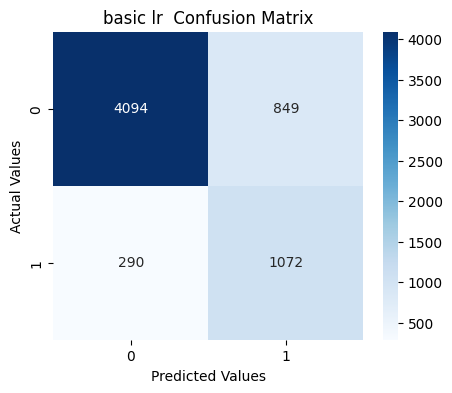

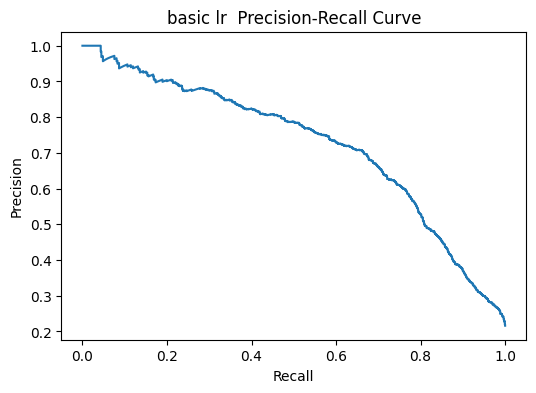

In [72]:
# Redefining the function with correct variable names to fix the UnboundLocalError and typos
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

def eval_model(model_name, model, X_test, y_test,threshold=None):

      # y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    if threshold is not None:
        y_pred = (y_pred_prob >= threshold).astype(int)
    else:
        y_pred = model.predict(X_test)

    # Calculate metrics with distinct variable names to avoid shadowing the imported functions
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1_val = f1_score(y_test, y_pred)

    print(f"Accuracy : {acc:.2f}")
    print(f"Precision : {prec:.2f}")
    print(f"Recall : {rec:.2f}")
    print(f"F1 : {f1_val:.2f}")
    print()

    # Classification report
    class_report = classification_report(y_test, y_pred)
    print(f"{model_name} Classification Report:")
    print(class_report)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel("Actual Values")
    plt.xlabel("Predicted Values")
    plt.show()

    # Precision-Recall Curve
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(recalls, precisions)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} Precision-Recall Curve")
    plt.show()

# Evaluate the model
eval_model("basic lr ", basline_model, X_test, y_test)

Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

basic lr  Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



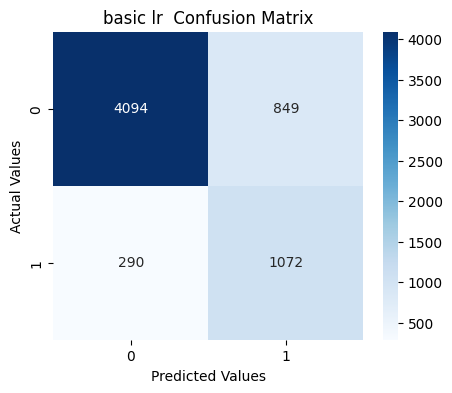

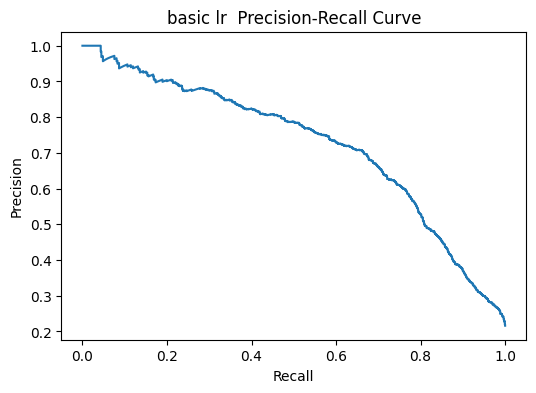

In [73]:
eval_model("basic lr ", basline_model, X_test, y_test)

#10. XGBoost Hyperparameter Tuning
Now we move to a stronger model, XGBoost.

In [74]:
xgb = Pipeline(
    [('preprocessor',xgb_cv_pipeline),
    ("classifier",
            XGBClassifier(
                n_estimators=1000,
                learning_rate=0.01,
                scale_pos_weight=class_weights,
                random_state=42,
            )
    )
     ]
)
xgb

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('preprocessor',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='median'))]),
                                                                   ['person_age',
                                                                    'person_income',
                                                                    'person_emp_length',
                                                                    'loan_amnt',
                                                                    'loan_int_rate',
                                                                    'loan_percent_income',
                                                                    'cb_person_cred_hist_length']),
                                                                  ('cat',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(fill_...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=1000, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [75]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_grid = {
    "classifier__n_estimators": randint(150, 600),
    "classifier__max_depth" : randint(3,9),
    "classifier__learning_rate" : uniform(0.01, 0.5),
    "classifier__subsample": uniform(0.6,0.4), #Rows sampling
    "classifier__colsample_bytree" :uniform(0.6,0.4), #column sampling
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0 , 5)
}
# lower gamma -> more splits  -> complex tree -> higher overfitting risk
# higher gamma -> less splits ->  simpler tree -> low overfitting

In [76]:
random_search = RandomizedSearchCV(
    xgb,
    param_grid,
    n_iter=20,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)

In [77]:
# 1. Redefine the xgb Pipeline correctly using preprocessor_xg
xgb = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(scale_pos_weight=class_weights, random_state=42))
])

# 2. Re-initialize the RandomizedSearchCV with the corrected pipeline
random_search = RandomizedSearchCV(
    xgb,
    param_grid,
    n_iter=20,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# 3. Fit the model
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79b2db90f4d0>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79b2e41e3380>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79b2db90f110>},
                   random_state=42, scoring='average_precision', verbose=1)

In [78]:
df.shape

(32581, 12)

In [79]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [80]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.8493192507310232),
 'classifier__gamma': np.float64(1.654490124263246),
 'classifier__learning_rate': np.float64(0.04177917514301182),
 'classifier__max_depth': 8,
 'classifier__min_child_weight': 8,
 'classifier__n_estimators': 442,
 'classifier__subsample': np.float64(0.8918424713352255)}

In [81]:
random_search.best_score_

np.float64(0.903708014719621)

Accuracy : 0.93
Precision : 0.85
Recall : 0.80
F1 : 0.83

XGB Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      4943
           1       0.85      0.80      0.83      1362

    accuracy                           0.93      6305
   macro avg       0.90      0.88      0.89      6305
weighted avg       0.93      0.93      0.93      6305



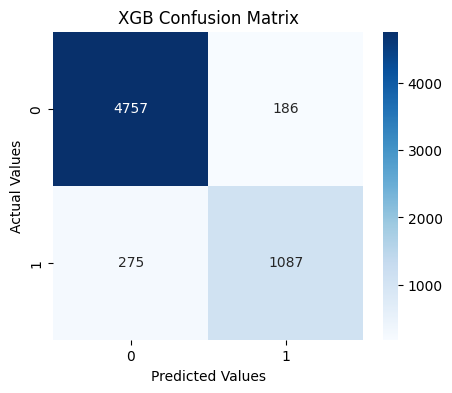

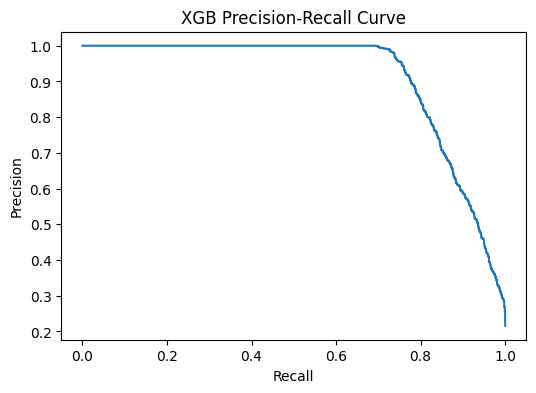

In [82]:
eval_model("XGB",random_search,X_test,y_test)

In [83]:
prob = random_search.predict_proba(X_test)[:,1]

precision,recall,thresholds = precision_recall_curve(y_test,prob)

f1 = 2 * (precision * recall) / (precision + recall + 1e-9)
ix = np.argmax(f1)
# print(f'Best Threshold={thresholds[ix]}, F1-Score={f1[ix]:.3f}')
best = np.argmax(f1[:-1])
best_threshold=thresholds[best]
best

np.int64(5227)

In [84]:
best_threshold

np.float32(0.6607561)

#13. Probability Calibration
Sometimes a model's probability doesn't mean what it says.
For example, 30% risk should truly mean a 30% chance.
We check this with a calibration plot.
We fix it if the probabilities are off.

In [85]:


"""
Methods by which we can fix the poorly calibrated model.
1. Platt Scaling/ Sigmoid -> Adjust the probabilites using a sigmoid curve.
2. Isotonic Regression -> Learn a flexible mapping from old prob. - better prob. (non-linear calibartion)
3. Temperature Scaling -> Adjust the confidence of neural-network predictions using one temperature
"""



'\nMethods by which we can fix the poorly calibrated model.\n1. Platt Scaling/ Sigmoid -> Adjust the probabilites using a sigmoid curve.\n2. Isotonic Regression -> Learn a flexible mapping from old prob. - better prob. (non-linear calibartion)\n3. Temperature Scaling -> Adjust the confidence of neural-network predictions using one temperature\n'

In [86]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(random_search, cv=cv, method="sigmoid")
calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_le...
                                                                feature_weights=None,
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=None,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=None,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=None,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [87]:
uncalibrated_prob = random_search.predict_proba(X_test)[:, 1]
calibrated_prob = calibrated_model.predict_proba(X_test)[:, 1]
uncalibrated_prob

array([0.63906735, 0.07930414, 0.98985505, ..., 0.66709596, 0.05209194,
       0.01251756], dtype=float32)

In [88]:
calibrated_prob

array([0.74885411, 0.03081865, 0.94188093, ..., 0.43181114, 0.02118638,
       0.01748255])

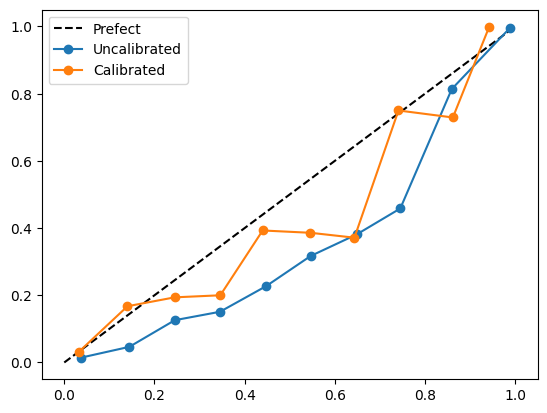

In [92]:
#3. create calibration curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated_prob, n_bins=10)


actual_cal, predicted_cal  = calibration_curve(y_test, calibrated_prob, n_bins=10)


#4. plot
plt.plot([0,1], [0,1], 'k--', label="Prefect")
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "Calibrated"
)
plt.legend()


In [89]:

#1. Install SHAP if not exists
!pip install shap
import shap


In [101]:
xgb_class = random_search.best_estimator_.named_steps['classifier']
xgb_class

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.8493192507310232), device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=np.float64(1.654490124263246), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.04177917514301182), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=8, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=442, n_jobs=None,
              num_parallel_tree=None, ...)

In [100]:
# Extract the fitted preprocessor from the best estimator of the randomized search
X_test_transformed = random_search.best_estimator_.named_steps['preprocessor']
X_test_transformed.transform(X_test)

array([[2.4000e+01, 3.0000e+04, 1.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [2.3000e+01, 6.0000e+04, 6.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [2.9000e+01, 1.8000e+04, 2.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       ...,
       [2.5000e+01, 4.8996e+04, 8.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [2.7000e+01, 1.1500e+05, 1.1000e+01, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [3.2000e+01, 5.0000e+04, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00]])

In [104]:
feature_name = random_search.best_estimator_['preprocessor'].get_feature_names_out()

In [106]:
# Get the actual transformed numpy array first
X_test_transformed_array = random_search.best_estimator_.named_steps['preprocessor'].transform(X_test)

# convert to a df for cleaner shap plots using the transformed array
X_test_df = pd.DataFrame(X_test_transformed_array, columns=feature_name)
X_test_df

,num__person_age,num__person_income,num__person_emp_length,num__loan_amnt,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,...,cat__loan_intent_VENTURE,cat__loan_grade_A,cat__loan_grade_B,cat__loan_grade_C,cat__loan_grade_D,cat__loan_grade_E,cat__loan_grade_F,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y
0,24.0,30000.0,1.0,15000.0,15.68,0.50,3.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,23.0,60000.0,6.0,25600.0,10.99,0.43,4.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,29.0,18000.0,2.0,3600.0,15.27,0.20,6.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,32.0,130000.0,7.0,13000.0,12.69,0.10,8.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,23.0,45288.0,7.0,20500.0,9.25,0.45,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6300,21.0,75000.0,5.0,20000.0,13.11,0.27,2.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
6301,29.0,265000.0,2.0,25000.0,11.26,0.09,10.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6302,25.0,48996.0,8.0,5000.0,9.88,0.10,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6303,27.0,115000.0,11.0,8000.0,7.51,0.07,7.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [110]:
X_test.shape

(6305, 11)

In [109]:
#6. Create SHAP explainer built for tree-based model
explainer = shap.TreeExplainer(xgb_class)

In [111]:
shap_values = explainer.shap_values(X_test_df)

In [113]:
shap_values.shape

(6305, 26)

In [114]:
X_test_df.shape

(6305, 26)

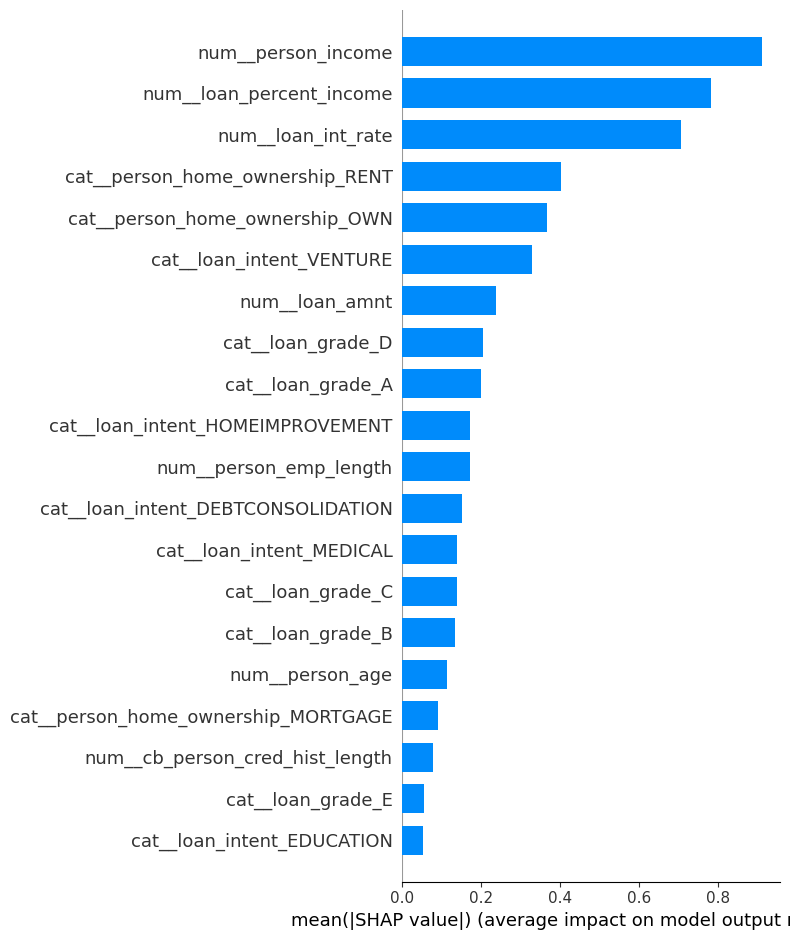

In [117]:
shap.summary_plot(shap_values, X_test_df, plot_type="bar")

In [119]:
shap.summary_plot(shap_values<, X_test_df)

SyntaxError: invalid syntax (931667718.py, line 1)

In [122]:
row_index=5
# Initialize Javascript visualization for SHAP
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[row_index,:], X_test_df.iloc[row_index,:])

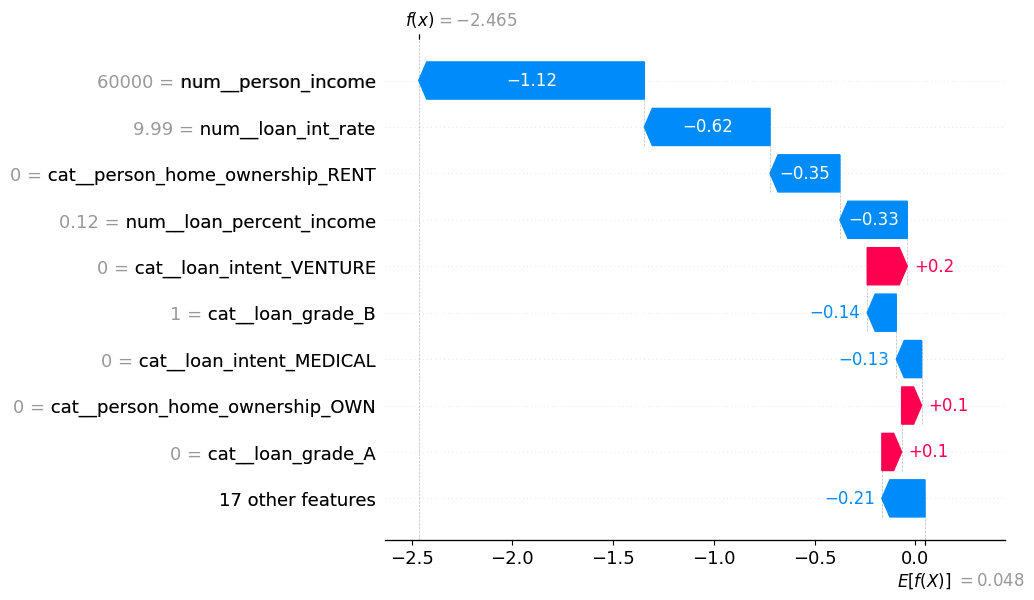

In [123]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[row_index],
        base_values=explainer.expected_value,
        data=X_test_df.iloc[row_index],
        feature_names=feature_name
    )
)

#15. Analyzing False Positives & False Negatives
The model will not be perfect.

False positives are safe people wrongly marked risky.

False negatives are risky people wrongly marked safe.

We study these cases to understand where the model struggles.

In [124]:

#Get predictions from the best performing XGBoost model on the test set
y_pred = random_search.predict(X_test)

In [125]:
y_pred

array([1, 0, 1, ..., 1, 0, 0])

In [126]:

#Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [129]:
result_df.sample(8)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,actual,predicted
4522,24,69000,RENT,2.0,DEBTCONSOLIDATION,D,4800,15.21,0.07,N,4,1,1
3626,21,38000,MORTGAGE,5.0,EDUCATION,C,7000,13.49,0.18,Y,3,0,0
18821,31,27036,MORTGAGE,2.0,EDUCATION,B,6500,11.11,0.24,N,7,0,0
17718,24,30000,RENT,6.0,PERSONAL,E,7750,NaN,0.26,N,4,0,1
25054,29,27000,RENT,1.0,DEBTCONSOLIDATION,D,12000,13.24,0.44,Y,6,1,1
30101,43,45996,MORTGAGE,2.0,EDUCATION,A,6300,7.51,0.14,N,14,0,0
11431,25,60000,RENT,2.0,HOMEIMPROVEMENT,C,10000,12.09,0.17,N,2,0,0
16793,24,57000,MORTGAGE,5.0,HOMEIMPROVEMENT,A,8000,5.42,0.14,N,4,0,0


In [134]:
fp = result_df[(result_df['actual'] == 0) & (result_df['predicted'] == 1)]
fn = result_df[(result_df['actual'] == 1 )& (result_df['predicted'] == 0)]

In [135]:

print(f"False Positive : {len(fp)}")
print(f"False Negative : {len(fn)}")

False Positive : 186
False Negative : 275


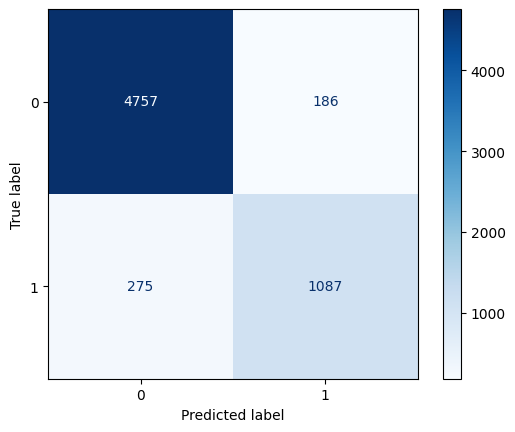

In [141]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.show()

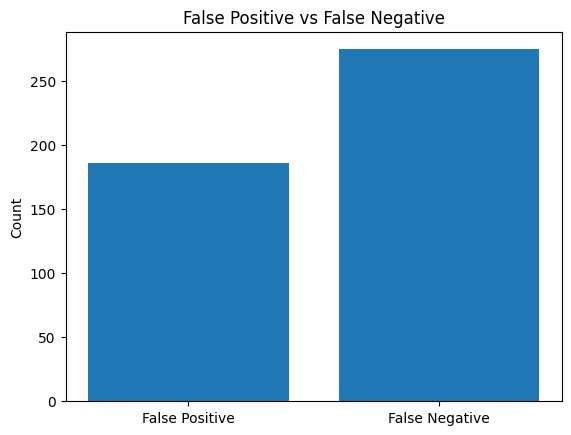

In [142]:

plt.bar(["False Positive", "False Negative"], [186, 275])
plt.ylabel("Count")
plt.title("False Positive vs False Negative")
plt.show()

In [146]:
import joblib
joblib.dump(calibrated_model,'credit_risk_model.pkl')
joblib.dump(best_threshold,'best_threshold.pkl')


['best_threshold.pkl']

In [145]:
best_threshold

np.float32(0.6607561)